# Componente práctico

## 2.1 Construcción de los arreglos

- Digitos resultantes: [1, 7, 4, 7, 7, 5, 1, 5, 4, 7]

- Arreglo 1 (signos alternados): [1, -7, 4, -7, 7, -5, 1, -5, 4, -7]

- Arreglo 2 (sin signos): [1, 7, 4, 7, 7, 5, 1, 5, 4, 7]

In [1]:
DOC = "1040751547"

# reemplazo de ceros
reemplazo = next(d for d in reversed(DOC) if d != '0')
digitos = [int(d) if d != '0' else int(reemplazo) for d in DOC]

# arreglo 1
arr1 = [d if i % 2 == 0 else -d for i, d in enumerate(digitos)]

# arreglo 2
arr2 = digitos.copy()

print("Arreglo 1:", arr1)
print("Arreglo 2:", arr2)

Arreglo 1: [1, -7, 4, -7, 7, -5, 1, -5, 4, -7]
Arreglo 2: [1, 7, 4, 7, 7, 5, 1, 5, 4, 7]


## 2.2. Ejercicio 1: Solución manual del problema del subarreglo máximo

División recursiva del arreglo
```
[0-9]
├── [0-4]
│   ├── [0-2]
│   │   ├── [0-1]
│   │   │   ├── [0] = 1
│   │   │   └── [1] = -7
│   │   └── [2] = 4
│   └── [3-4]
│       ├── [3] = -7
│       └── [4] = 7
└── [5-9]
    ├── [5-7]
    │   ├── [5-6]
    │   │   ├── [5] = -5
    │   │   └── [6] = 1
    │   └── [7] = -5
    └── [8-9]
        ├── [8] = 4
        └── [9] = -7
```



Mitad izquierda `[0–4]`: `[1, -7, 4, -7, 7]`

*   Mejor izquierda: `4`
*   Mejor derecha: `7`
*   Cruzado: `4 + (-7) + 7 = 4`
*   Resultado: `7`


Mitad derecha `[5–9]`: `[-5, 1, -5, 4, -7]`
*   Mejor izquierda: `1`
*   Mejor derecha: `4`
*   Cruzado: `1 + (-5) + 4 = 0`
*   Resultado: `4`

Subarreglo cruzado global (centro entre índice 4 y 5)<br>

Izquierda desde índice 4 hacia atrás: <br>
`7` (mejor)

Derecha desde índice 5 hacia adelante: <br>
`-5 + 1 = -4`, luego baja → mejor: `-4`

Cruzado total: <br>
`7 + (-4) = 3`

Comparación final

*   Izquierda: `7`
*   Derecha: `4`
*   Cruzado: `3`

Resultado final

Subarreglo máximo: <br>
`[7]` (posición 4) <br>
Suma máxima: **7**


## 2.3. Ejercicio 2: Solución manual del algoritmo Merge Sort

#### Arreglo a ordenar:

`[1, 7, 4, 7, 7, 5, 1, 5, 4, 7]`

#### Divisiones sucesivas del arreglo hasta alcanzar el caso base


```
[1,7,4,7,7,5,1,5,4,7]
├── [1,7,4,7,7]
│   ├── [1,7]
│   │   ├── [1]
│   │   └── [7]
│   └── [4,7,7]
│       ├── [4]
│       └── [7,7]
│           ├── [7]
│           └── [7]
└── [5,1,5,4,7]
    ├── [5,1]
    │   ├── [5]
    │   └── [1]
    └── [5,4,7]
        ├── [5]
        └── [4,7]
            ├── [4]
            └── [7]
```

#### Identificación del caso base

Arreglos de un solo elemento: <br>
`[1], [7], [4], [7], [7], [5], [1], [5], [4], [7]`

#### Proceso de mezcla paso a paso

*   `[1] + [7] → [1,7]`
*   `[7] + [7] → [7,7]`
*   `[4] + [7,7] → [4,7,7]`
*   `[1,7] + [4,7,7] → [1,4,7,7,7]`
*   `[5] + [1] → [1,5]`
*   `[4] + [7] → [4,7]`
*   `[5] + [4,7] → [4,5,7]`
*   `[1,5] + [4,5,7] → [1,4,5,5,7]`

#### Resultado final ordenado
`[1,4,7,7,7] + [1,4,5,5,7] →`

Paso a paso: <br>
`[1,1,4,4,5,5,7,7,7,7]`

:## 2.4. Ejercicio 3: Implementación en Python del problema del subarreglo máximo

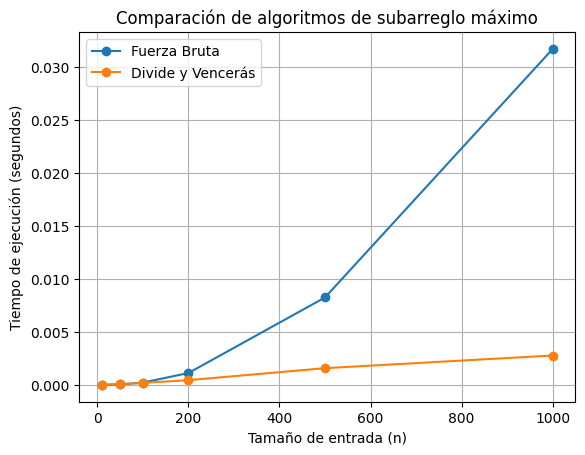

In [2]:
import random
import time
import matplotlib.pyplot as plt

# -----------------------------
# 1. Algoritmo fuerza bruta
# -----------------------------
def max_subarray_bruteforce(arr):
    max_sum = float('-inf')
    n = len(arr)
    for i in range(n):
        current = 0
        for j in range(i, n):
            current += arr[j]
            if current > max_sum:
                max_sum = current
    return max_sum

# -----------------------------
# 2. Divide y vencerás
# -----------------------------
def max_crossing(arr, left, mid, right):
    left_sum = float('-inf')
    total = 0
    for i in range(mid, left-1, -1):
        total += arr[i]
        left_sum = max(left_sum, total)

    right_sum = float('-inf')
    total = 0
    for i in range(mid+1, right+1):
        total += arr[i]
        right_sum = max(right_sum, total)

    return left_sum + right_sum

def max_subarray_dc(arr, left, right):
    if left == right:
        return arr[left]

    mid = (left + right) // 2

    return max(
        max_subarray_dc(arr, left, mid),
        max_subarray_dc(arr, mid+1, right),
        max_crossing(arr, left, mid, right)
    )

# -----------------------------
# 3. Pruebas de tiempo
# -----------------------------
sizes = [10, 50, 100, 200, 500, 1000]

bf_times = []
dc_times = []

for n in sizes:
    arr = [random.randint(-10, 10) for _ in range(n)]

    # Fuerza bruta
    start = time.time()
    max_subarray_bruteforce(arr)
    bf_times.append(time.time() - start)

    # Divide y vencerás
    start = time.time()
    max_subarray_dc(arr, 0, n-1)
    dc_times.append(time.time() - start)

# -----------------------------
# 4. Gráfica
# -----------------------------
plt.figure()
plt.plot(sizes, bf_times, marker='o', label='Fuerza Bruta')
plt.plot(sizes, dc_times, marker='o', label='Divide y Vencerás')

plt.xlabel("Tamaño de entrada (n)")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Comparación de algoritmos de subarreglo máximo")

plt.legend()
plt.grid()

plt.show()

#### Conclusiones:

*   Fuerza bruta crece muy rápido (≈ O(n²)), se vuelve ineficiente desde n≈200.
*   Divide y vencerás escala mucho mejor (≈ O(n log n)).
*   Para entradas grandes, divide y vencerás es claramente superior.
*   La diferencia de tiempos aumenta conforme crece n.

## 2.5. Ejercicio 4: Comparación experimental entre Merge Sort e Insertion Sort

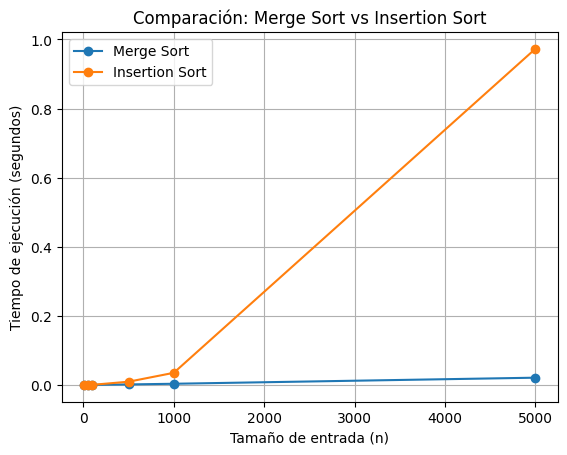

In [3]:
import random
import time
import matplotlib.pyplot as plt

# -----------------------------
# Merge Sort
# -----------------------------
def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0

    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result

# -----------------------------
# Insertion Sort
# -----------------------------
def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1

        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1

        arr[j + 1] = key
    return arr

# -----------------------------
# Pruebas de tiempo
# -----------------------------
sizes = [10, 50, 100, 500, 1000, 5000]

merge_times = []
insertion_times = []

for n in sizes:
    arr = [random.randint(0, 1000) for _ in range(n)]

    arr_copy1 = arr.copy()
    arr_copy2 = arr.copy()

    # Merge Sort
    start = time.time()
    merge_sort(arr_copy1)
    merge_times.append(time.time() - start)

    # Insertion Sort
    start = time.time()
    insertion_sort(arr_copy2)
    insertion_times.append(time.time() - start)

# -----------------------------
# Gráfica
# -----------------------------
plt.figure()
plt.plot(sizes, merge_times, marker='o', label='Merge Sort')
plt.plot(sizes, insertion_times, marker='o', label='Insertion Sort')

plt.xlabel("Tamaño de entrada (n)")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Comparación: Merge Sort vs Insertion Sort")

plt.legend()
plt.grid()

plt.show()

#### Conclusiones:

*   Merge Sort crece mucho más lento (≈ O(n log n)).
*   Insertion Sort se vuelve muy lento al aumentar n (≈ O(n²)).
*   Para n grandes (1000+), Merge Sort es claramente superior.




